In [2]:
from datetime import datetime, timedelta
import dukascopy_python
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_EUR_USD
import pandas as pd



In [3]:
start = datetime(2020, 1, 1)
end = datetime(2025, 12, 31)

raw_ticks = dukascopy_python.fetch(
    instrument=INSTRUMENT_FX_MAJORS_EUR_USD,
    interval=dukascopy_python.INTERVAL_TICK,
    offer_side=dukascopy_python.OFFER_SIDE_BID,
    start=start,
    end=end,
)

print(f"Fetched {len(raw_ticks):,} ticks")
print(f"Columns: {list(raw_ticks.columns)}")
print(f"Range: {raw_ticks.index.min()} -> {raw_ticks.index.max()}")
raw_ticks.head()

INFO:DUKASCRIPT:current timestamp :2020-01-02T11:37:00.557000
INFO:DUKASCRIPT:current timestamp :2020-01-02T17:04:10.677000
INFO:DUKASCRIPT:current timestamp :2020-01-03T04:21:00.929000
INFO:DUKASCRIPT:current timestamp :2020-01-03T11:44:25.722000
INFO:DUKASCRIPT:current timestamp :2020-01-03T17:07:35.864000
INFO:DUKASCRIPT:current timestamp :2020-01-06T04:04:37.461000
INFO:DUKASCRIPT:current timestamp :2020-01-06T12:22:26.888000
INFO:DUKASCRIPT:current timestamp :2020-01-06T19:36:53.598000
INFO:DUKASCRIPT:current timestamp :2020-01-07T09:28:48.544000
INFO:DUKASCRIPT:current timestamp :2020-01-07T15:00:10.102000
INFO:DUKASCRIPT:current timestamp :2020-01-07T22:52:36.221000
INFO:DUKASCRIPT:current timestamp :2020-01-08T04:58:01.375000
INFO:DUKASCRIPT:current timestamp :2020-01-08T11:16:25.916000
INFO:DUKASCRIPT:current timestamp :2020-01-08T16:36:34.943000
INFO:DUKASCRIPT:current timestamp :2020-01-09T01:29:02.555000
INFO:DUKASCRIPT:current timestamp :2020-01-09T11:04:40.045000
INFO:DUK

Fetched 158,165,983 ticks
Columns: ['bidPrice', 'askPrice', 'bidVolume', 'askVolume']
Range: 2020-01-01 22:00:00.065000+00:00 -> 2025-12-30 22:59:47.863000+00:00


,bidPrice,askPrice,bidVolume,askVolume
timestamp,,,,
2020-01-01 22:00:00.065000+00:00,1.12120,1.12172,0.75,0.75
2020-01-01 22:00:10.447000+00:00,1.12120,1.12192,0.75,0.75
2020-01-01 22:00:10.498000+00:00,1.12117,1.12161,0.75,0.56
2020-01-01 22:00:12.579000+00:00,1.12120,1.12161,0.75,0.56
2020-01-01 22:00:12.630000+00:00,1.12120,1.12172,1.50,0.56


In [3]:
#raw_ticks.to_csv("ticks_data.csv")


In [4]:
#raw_ticks = pd.read_csv("ticks_data.")

In [4]:
raw_ticks.index.dtype

datetime64[ms, UTC]

In [5]:
raw_ticks['mid'] = (raw_ticks['bidPrice']+ raw_ticks['askPrice'])/2
raw_ticks['mid'].head()

timestamp
2020-01-01 22:00:00.065000+00:00    1.121460
2020-01-01 22:00:10.447000+00:00    1.121560
2020-01-01 22:00:10.498000+00:00    1.121390
2020-01-01 22:00:12.579000+00:00    1.121405
2020-01-01 22:00:12.630000+00:00    1.121460
Name: mid, dtype: float64

In [7]:
raw_ticks['volume'] = raw_ticks['bidVolume'] + raw_ticks['askVolume']
raw_ticks['volume'].head()

timestamp
2020-01-01 22:00:00.065000+00:00    1.50
2020-01-01 22:00:10.447000+00:00    1.50
2020-01-01 22:00:10.498000+00:00    1.31
2020-01-01 22:00:12.579000+00:00    1.31
2020-01-01 22:00:12.630000+00:00    2.06
Name: volume, dtype: float64

In [8]:
fivemin_bars=raw_ticks.resample('5min').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )
fivemin_bars.head(5)

,open,high,low,close,vol,tick_count
timestamp,,,,,,
2020-01-01 22:00:00+00:00,1.121460,1.121585,1.121330,1.121380,110.3936,67
2020-01-01 22:05:00+00:00,1.121380,1.121510,1.121300,1.121430,105.9700,42
2020-01-01 22:10:00+00:00,1.121425,1.121445,1.121235,1.121395,99.0700,52
2020-01-01 22:15:00+00:00,1.121385,1.121600,1.121355,1.121485,170.2400,107
2020-01-01 22:20:00+00:00,1.121475,1.121605,1.121440,1.121550,254.9900,163


In [9]:
onehour_bars = raw_ticks.resample('1h').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )
onehour_bars.head(5)

,open,high,low,close,vol,tick_count
timestamp,,,,,,
2020-01-01 22:00:00+00:00,1.121460,1.121695,1.121235,1.121500,2125.9036,1432
2020-01-01 23:00:00+00:00,1.121505,1.122225,1.121495,1.121895,2962.4600,1363
2020-01-02 00:00:00+00:00,1.121900,1.121915,1.121580,1.121840,3699.7200,1268
2020-01-02 01:00:00+00:00,1.121830,1.122455,1.121810,1.122110,6495.5600,2204
2020-01-02 02:00:00+00:00,1.122110,1.122460,1.121850,1.122240,4986.5600,1473


In [10]:
sixhour_bars = raw_ticks.resample('6h').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )

In [11]:
eighthour_bars = raw_ticks.resample('8h').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )

In [12]:
import numpy as np
import pandas as pd

In [13]:
fivemin_bars['Y'] = np.log(fivemin_bars['close']/fivemin_bars['close'].shift(1)) 
# Yt is the return variable that has been used in the Paper. 
fivemin_bars['Y'].shape
onehour_bars['Y'] = np.log(onehour_bars['close']/onehour_bars['close'].shift(1))
sixhour_bars['Y'] = np.log(sixhour_bars['close']/sixhour_bars['close'].shift(1)) 
eighthour_bars['Y'] = np.log(eighthour_bars['close']/eighthour_bars['close'].shift(1)) 






In [14]:
fivemin_bars['Y'].head(10)

timestamp
2020-01-01 22:00:00+00:00             NaN
2020-01-01 22:05:00+00:00    4.458692e-05
2020-01-01 22:10:00+00:00   -3.121064e-05
2020-01-01 22:15:00+00:00    8.025396e-05
2020-01-01 22:20:00+00:00    5.795719e-05
2020-01-01 22:25:00+00:00   -4.458126e-06
2020-01-01 22:30:00+00:00    2.220446e-16
2020-01-01 22:35:00+00:00    2.229043e-05
2020-01-01 22:40:00+00:00    8.916033e-06
2020-01-01 22:45:00+00:00    2.228974e-05
Freq: 5min, Name: Y, dtype: float64

In [15]:
type(fivemin_bars['Y'])

pandas.Series

In [16]:
tenmin_bars=raw_ticks.resample('10min').agg(open =('mid', 'first'),
                                            high =('mid', 'max'), 
                                            low=('mid', 'min'), 
                                            close=('mid', 'last'),
                                            vol=('volume', 'sum'),
                                            tick_count=('mid', 'count') )
    
tenmin_bars.head(10)

,open,high,low,close,vol,tick_count
timestamp,,,,,,
2020-01-01 22:00:00+00:00,1.121460,1.121585,1.121300,1.121430,216.3636,109
2020-01-01 22:10:00+00:00,1.121425,1.121600,1.121235,1.121485,269.3100,159
2020-01-01 22:20:00+00:00,1.121475,1.121605,1.121440,1.121545,285.3600,183
2020-01-01 22:30:00+00:00,1.121565,1.121600,1.121490,1.121570,108.7500,97
2020-01-01 22:40:00+00:00,1.121580,1.121645,1.121550,1.121605,659.1400,511
2020-01-01 22:50:00+00:00,1.121610,1.121695,1.121500,1.121500,586.9800,373
2020-01-01 23:00:00+00:00,1.121505,1.122225,1.121495,1.122010,1239.9600,706
2020-01-01 23:10:00+00:00,1.122015,1.122080,1.121970,1.121995,195.6700,89
2020-01-01 23:20:00+00:00,1.121995,1.122120,1.121975,1.122115,353.5500,114


In [17]:
tenmin_bars['Y'] = np.log(tenmin_bars['close'] / tenmin_bars['close'].shift(1))
tenmin_bars['Y'].head(10)

timestamp
2020-01-01 22:00:00+00:00         NaN
2020-01-01 22:10:00+00:00    0.000049
2020-01-01 22:20:00+00:00    0.000053
2020-01-01 22:30:00+00:00    0.000022
2020-01-01 22:40:00+00:00    0.000031
2020-01-01 22:50:00+00:00   -0.000094
2020-01-01 23:00:00+00:00    0.000455
2020-01-01 23:10:00+00:00   -0.000013
2020-01-01 23:20:00+00:00    0.000107
2020-01-01 23:30:00+00:00    0.000036
Freq: 10min, Name: Y, dtype: float64

In [18]:
y5 = fivemin_bars['Y'].dropna()
y10 = tenmin_bars['Y'].dropna()

In [19]:
from scipy.stats import moment, skew, kurtosis


In [20]:
def get_stats(series, name):
    s=series.dropna()
    return{ 'series': name,
        'mean': s.mean(),
        'variance': moment(s, moment=2),
        'm3': moment(s, moment=3),
        'm4': moment(s, moment=4),
        'm5': moment(s, moment=5),
        'm6': moment(s, moment=6),
        'skewness': skew(s),
        'kurtosis': kurtosis(s, fisher=False),
    }

In [21]:
results =[]
results.append(get_stats(fivemin_bars['Y'], 'Returns (5min)'))
results.append(get_stats(tenmin_bars['Y'], 'Returns (10min)'))
results.append(get_stats(fivemin_bars['vol'], 'volume5min'))
results.append(get_stats(tenmin_bars['vol'], 'volume10min'))
results.append(get_stats(fivemin_bars['tick_count'], 'tick5min'))
results.append(get_stats(tenmin_bars['tick_count'], 'tick10min'))

In [22]:
results

[{'series': 'Returns (5min)',
  'mean': np.float64(1.846439300896675e-07),
  'variance': np.float64(8.601712815741668e-08),
  'm3': np.float64(9.345829477981305e-14),
  'm4': np.float64(3.5682064852306287e-13),
  'm5': np.float64(3.3800149365613625e-16),
  'm6': np.float64(2.0808069939672292e-17),
  'skewness': np.float64(0.003704592512528719),
  'kurtosis': np.float64(48.22587329296559)},
 {'series': 'Returns (10min)',
  'mean': np.float64(3.2187476453284284e-07),
  'variance': np.float64(1.695666190507297e-07),
  'm3': np.float64(4.0732094173468925e-12),
  'm4': np.float64(9.651908169202239e-13),
  'm5': np.float64(1.3799702758619879e-15),
  'm6': np.float64(6.25288624763395e-17),
  'skewness': np.float64(0.058334596440459185),
  'kurtosis': np.float64(33.56854050282005)},
 {'series': 'volume5min',
  'mean': np.float64(1230.951234650078),
  'variance': np.float64(3874602.858080601),
  'm3': np.float64(65909871705.12681),
  'm4': np.float64(5363764976253770.0),
  'm5': np.float64(6.70

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

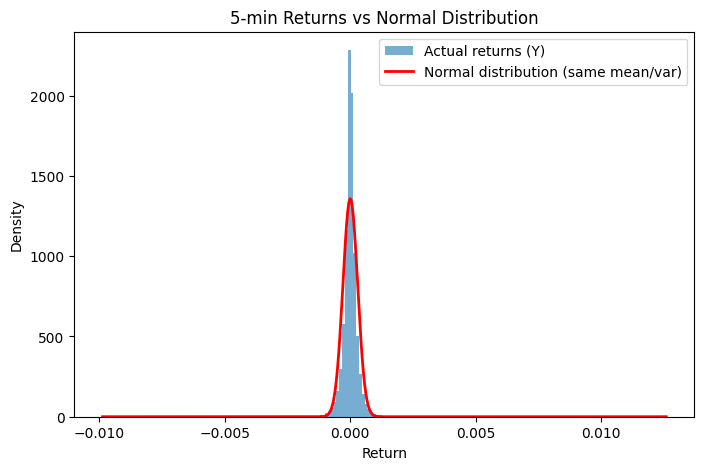

In [24]:
# Normal distribution with same mean/variance as our data
mu, sigma = y5.mean(), y5.std()
x_range = np.linspace(y5.min(), y5.max(), 500)
normal_curve = norm.pdf(x_range, mu, sigma)

plt.figure(figsize=(8,5))
plt.hist(y5, bins=200, density=True, alpha=0.6, label='Actual returns (Y)')
plt.plot(x_range, normal_curve, 'r-', linewidth=2, label='Normal distribution (same mean/var)')
plt.legend()
plt.title('5-min Returns vs Normal Distribution')
plt.xlabel('Return')
plt.ylabel('Density')
plt.show()



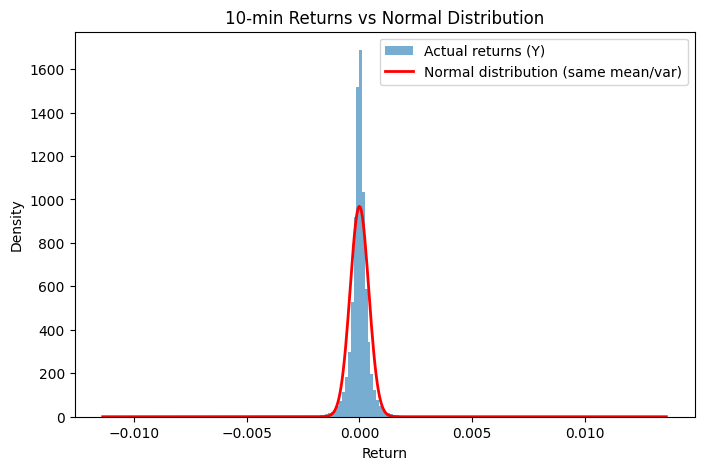

In [25]:
mu, sigma = y10.mean(), y10.std()
x_range = np.linspace(y10.min(), y10.max(), 500)
normal_curve = norm.pdf(x_range, mu, sigma)

plt.figure(figsize=(8,5))
plt.hist(y10, bins=200, density=True, alpha=0.6, label='Actual returns (Y)')
plt.plot(x_range, normal_curve, 'r-', linewidth=2, label='Normal distribution (same mean/var)')
plt.legend()
plt.title('10-min Returns vs Normal Distribution')
plt.xlabel('Return')
plt.ylabel('Density')
plt.show()

REGRESSION 
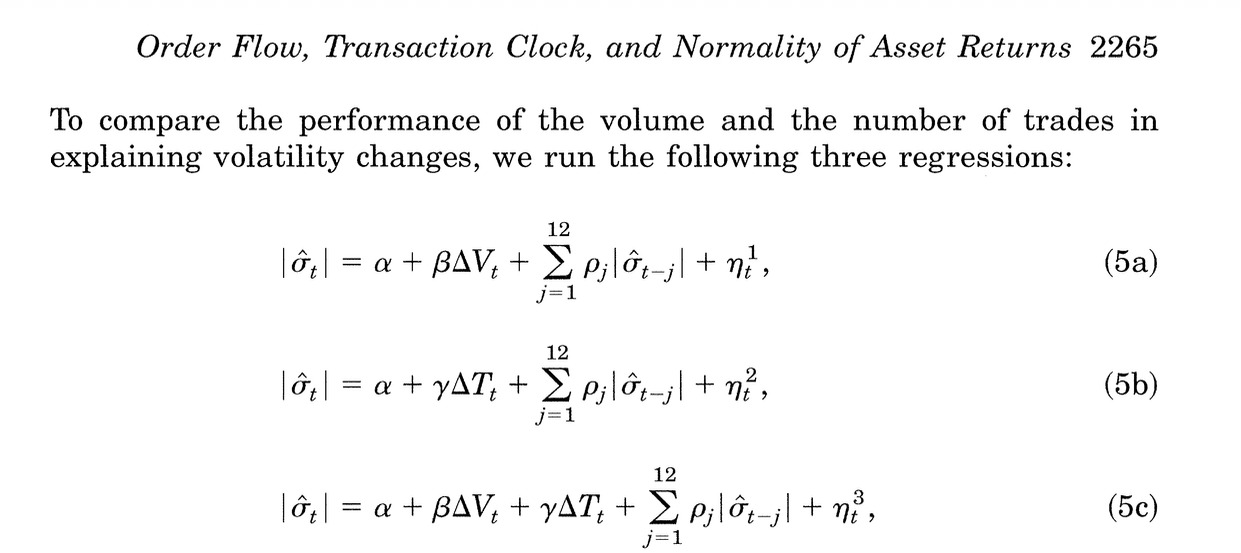

In [26]:
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg, gaussian_kde

In [27]:
def run_volatility_regressions(bars_df, label=""):
    y = bars_df['Y'].dropna()
    
    model = AutoReg(y, lags=12, old_names=False).fit()
    residuals = model.resid
    sigma_hat = np.sqrt(np.pi/2) * np.abs(residuals)
    
    delta_V = bars_df['vol'].diff()
    delta_T = bars_df['tick_count'].diff()
    
    reg_data = pd.DataFrame({'sigma_hat': sigma_hat})
    for lag in range(1, 13):
        reg_data[f'sigma_lag{lag}'] = reg_data['sigma_hat'].shift(lag)
    reg_data['delta_V'] = delta_V
    reg_data['delta_T'] = delta_T
    reg_data = reg_data.dropna()
    
    lag_cols = [f'sigma_lag{i}' for i in range(1, 13)]
    
    X_5a = sm.add_constant(reg_data[['delta_V'] + lag_cols])
    model_5a = sm.OLS(reg_data['sigma_hat'], X_5a).fit()
    
    X_5b = sm.add_constant(reg_data[['delta_T'] + lag_cols])
    model_5b = sm.OLS(reg_data['sigma_hat'], X_5b).fit()
    
    X_5c = sm.add_constant(reg_data[['delta_V', 'delta_T'] + lag_cols])
    model_5c = sm.OLS(reg_data['sigma_hat'], X_5c).fit()
    
    print(f"--- {label} ---")
    print("Adjusted R² (5a, volume only):", model_5a.rsquared_adj)
    print("Adjusted R² (5b, trade count only):", model_5b.rsquared_adj)
    print("Adjusted R² (5c, both):", model_5c.rsquared_adj)
    
    return model_5a, model_5b, model_5c, reg_data

In [28]:
def plot_kde(series, title, zero_filter=False, quantile_cutoff=0.99):
    s = series.dropna()
    if zero_filter:
        s = s[s > 0]
    
    n = len(s)
    sigma = s.std()
    h = sigma * (4/3)**(1/5) * n**(-1/5)#corrected silverman bandwidth
    bw_factor = h / sigma
    
    upper = s.quantile(quantile_cutoff)
    x_range = np.linspace(s.min(), upper, 500)
    density = gaussian_kde(s, bw_method=bw_factor)(x_range)
    
    plt.figure(figsize=(8,5))
    plt.plot(x_range, density)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel('Density')
    plt.show()

In [29]:
# Table I for both resolutions
results = []
for bars, res_name in [(fivemin_bars, '5min'), (tenmin_bars, '10min')]:
    results.append(get_stats(bars['Y'], f'Returns ({res_name})'))
    results.append(get_stats(bars['vol'], f'Volume ({res_name})'))
    results.append(get_stats(bars['tick_count'], f'Trade Count ({res_name})'))

table_I = pd.DataFrame(results)
table_I

,series,mean,variance,m3,m4,m5,m6,skewness,kurtosis
0,Returns (5min),1.846439e-07,8.601713e-08,9.345829e-14,3.568206e-13,3.380015e-16,2.080807e-17,0.003705,48.225873
1,Volume (5min),1.230951e+03,3.874603e+06,6.590987e+10,5.363765e+15,6.705945e+20,9.443390e+25,8.641909,357.285467
2,Trade Count (5min),2.507657e+02,9.901371e+04,7.661818e+07,1.251585e+11,2.281535e+14,4.811969e+17,2.459171,12.766437
3,Returns (10min),3.218748e-07,1.695666e-07,4.073209e-12,9.651908e-13,1.379970e-15,6.252886e-17,0.058335,33.568541
4,Volume (10min),2.461902e+03,1.411251e+07,2.733854e+11,2.121904e+16,3.090710e+21,5.539359e+26,5.156667,106.541180
5,Trade Count (10min),5.015315e+02,3.834182e+05,5.660507e+08,1.779919e+12,6.175193e+15,2.478817e+19,2.384220,12.107508


In [30]:
# Table II for both resolutions
run_volatility_regressions(fivemin_bars, label="5-min bars")
run_volatility_regressions(tenmin_bars, label="10-min bars")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


--- 5-min bars ---
Adjusted R² (5a, volume only): 0.22420930381161297
Adjusted R² (5b, trade count only): 0.29910419086966133
Adjusted R² (5c, both): 0.29913192816226986


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


--- 10-min bars ---
Adjusted R² (5a, volume only): 0.22344921133816542
Adjusted R² (5b, trade count only): 0.28994919524991036
Adjusted R² (5c, both): 0.2899739029056072


(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x72b5634950>,
                            sigma_hat  sigma_lag1  sigma_lag2  sigma_lag3  \
 timestamp                                                                  
 2020-01-02 02:10:00+00:00   0.000089    0.000187    0.000063    0.000340   
 2020-01-02 02:20:00+00:00   0.000163    0.000089    0.000187    0.000063   
 2020-01-02 02:30:00+00:00   0.000132    0.000163    0.000089    0.000187   
 2020-01-02 02:40:00+00:00   0.000168    0.000132    0.000163    0.000089   
 2020-01-02 02:50:00+00:00   0.000221    0.000168    0.000132    0.000163   
 ...                              ...         ...         ...         ...   
 2025-12-30 22:10:00+00:00   0.000209    0.000178    0.000083    0.000099   
 2025-12-30 22:20:00+00:00   0.000004    0.000209    0.000178    0.000083   
 2025-12-30 22:30:00+00:00   0.000038    0.000004    0.000209    0.000178   
 2025-12-30 22:40:00+00:00   0.000185    0.000038    0.000004    0.00020

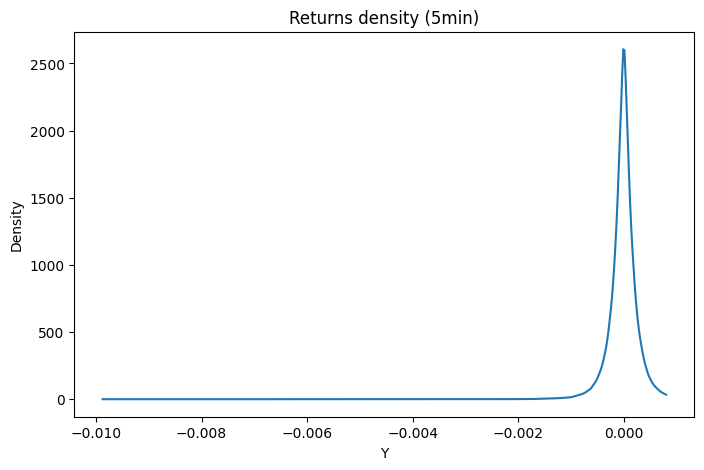

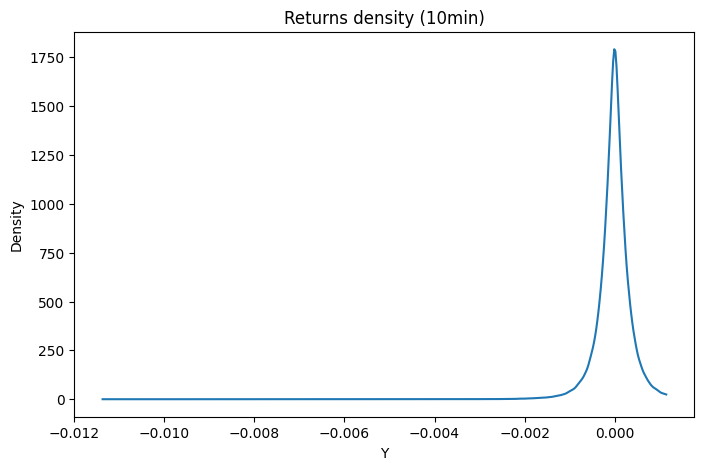

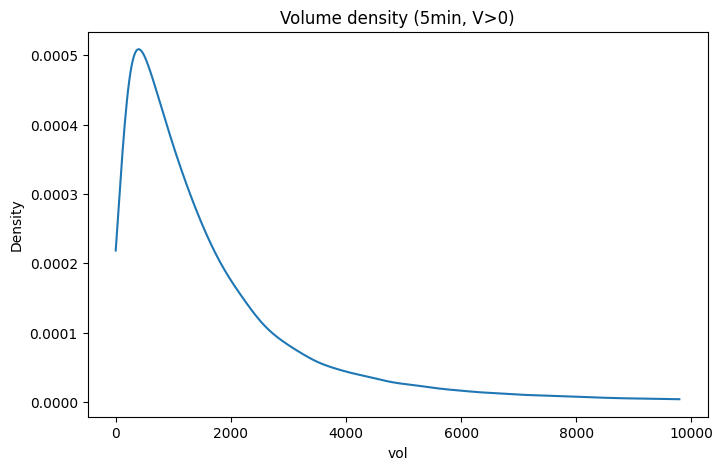

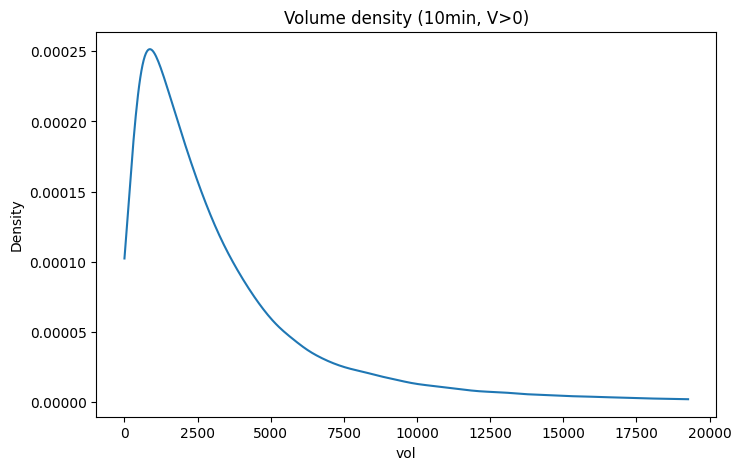

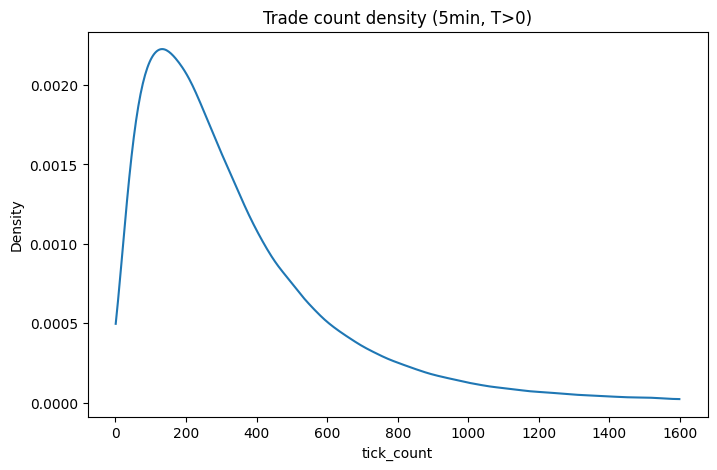

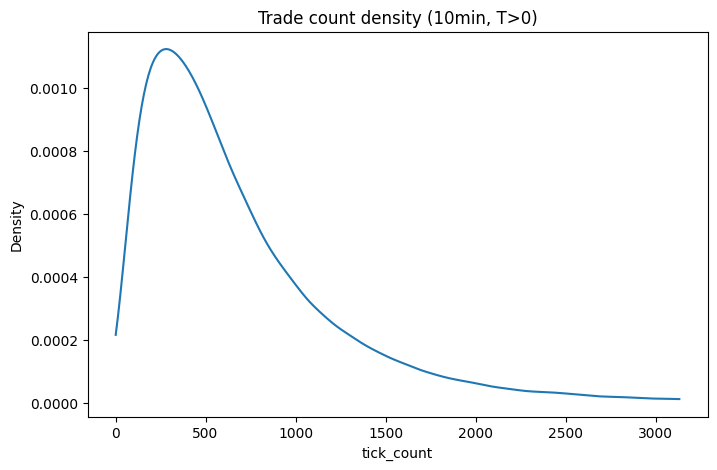

In [31]:
# KDE plots for both resolutions
plot_kde(fivemin_bars['Y'], 'Returns density (5min)')
plot_kde(tenmin_bars['Y'], 'Returns density (10min)')

plot_kde(fivemin_bars['vol'], 'Volume density (5min, V>0)', zero_filter=True)
plot_kde(tenmin_bars['vol'], 'Volume density (10min, V>0)', zero_filter=True)

plot_kde(fivemin_bars['tick_count'], 'Trade count density (5min, T>0)', zero_filter=True)
plot_kde(tenmin_bars['tick_count'], 'Trade count density (10min, T>0)', zero_filter=True)

MODEL III

In [32]:
#identify and report the weekend gaps
time_diffs = raw_ticks.index.to_series().diff()
big_gaps = time_diffs[time_diffs > pd.Timedelta(hours=6)]
print("Number of gaps > 6 hours:", len(big_gaps))
big_gaps.head(10)

Number of gaps > 6 hours: 317


timestamp
2020-01-05 22:00:22.039000+00:00   2 days 00:00:26.531000
2020-01-12 22:00:03.473000+00:00   2 days 00:01:00.715000
2020-01-19 22:00:39.388000+00:00   2 days 00:00:46.669000
2020-01-26 22:00:06.713000+00:00   2 days 00:00:10.298000
2020-02-02 22:00:14.503000+00:00   2 days 00:00:18.305000
2020-02-09 22:00:03.235000+00:00   2 days 00:00:06.909000
2020-02-16 22:00:01.861000+00:00   2 days 00:00:05.779000
2020-02-23 22:00:02.104000+00:00   2 days 00:00:05.815000
2020-03-01 22:00:01.729000+00:00   2 days 00:00:05.437000
2020-03-08 21:00:04.528000+00:00   1 days 23:00:07.847000
Name: timestamp, dtype: timedelta64[ms]

In [33]:
print("Total number of big gaps:", len(big_gaps))
big_gaps.describe()


Total number of big gaps: 317


count                       317
mean     1 days 23:48:57.636000
std      0 days 04:07:33.930000
min      0 days 14:04:01.811000
25%      2 days 00:00:03.245000
50%      2 days 00:00:06.288000
75%      2 days 00:00:51.331000
max      3 days 00:00:12.723000
Name: timestamp, dtype: object

In [34]:
# Choose N = ticks per bar.
# From our earlier 5-min bars, average tick_count was ~ (let's check)
avg_ticks_per_5min = fivemin_bars['tick_count'].mean()
print("Average ticks per 5-min bar:", avg_ticks_per_5min)

Average ticks per 5-min bar: 250.7657499540217


In [35]:
def build_tradecount_bars(raw_ticks_df, N):
    df_reset = raw_ticks_df.reset_index()
    df_reset['bar_id'] = df_reset.index // N
    
    bars = df_reset.groupby('bar_id').agg(
        start_time=('timestamp', 'first'),
        end_time=('timestamp', 'last'),
        open=('mid', 'first'),
        high=('mid', 'max'),
        low=('mid', 'min'),
        close=('mid', 'last'),
        vol=('volume', 'sum'),
        tick_count=('mid', 'count'),
    )
    
    bars['duration'] = bars['end_time'] - bars['start_time']
    bars['Y'] = np.log(bars['close'] / bars['close'].shift(1))
    
    return bars

In [36]:
N_5min = round(fivemin_bars['tick_count'].mean())
N_10min = round(tenmin_bars['tick_count'].mean())
N_1h = round(onehour_bars['tick_count'].mean())
N_6h = round(sixhour_bars['tick_count'].mean())
N_8h = round(eighthour_bars['tick_count'].mean())



print("N for 5-min equivalent:", N_5min)
print("N for 10-min equivalent:", N_10min)

N for 5-min equivalent: 251
N for 10-min equivalent: 502


In [37]:
tradecount_bars_5min = build_tradecount_bars(raw_ticks, N_5min)
tradecount_bars_10min = build_tradecount_bars(raw_ticks, N_10min)
tradecount_bars_1h = build_tradecount_bars(raw_ticks, N_1h)
tradecount_bars_6h = build_tradecount_bars(raw_ticks, N_6h)
tradecount_bars_8h = build_tradecount_bars(raw_ticks, N_8h)



tradecount_bars_5min.shape, tradecount_bars_10min.shape

((630144, 10), (315072, 10))

In [38]:
print(tradecount_bars_5min['duration'].describe())
print()
print(tradecount_bars_10min['duration'].describe())

count                    630144
mean     0 days 00:04:59.427000
std      0 days 01:05:00.951000
min      0 days 00:00:13.776000
25%      0 days 00:01:28.131000
50%      0 days 00:02:28.537000
75%      0 days 00:04:14.859000
max      3 days 00:11:45.071000
Name: duration, dtype: object

count                    315072
mean     0 days 00:09:59.706000
std      0 days 01:32:21.190000
min      0 days 00:00:27.830000
25%      0 days 00:03:00.400000
50%      0 days 00:05:01.660000
75%      0 days 00:08:35.038000
max      3 days 00:16:01.478000
Name: duration, dtype: object


In [39]:
def clean_tradecount_bars(bars, threshold_hours=6):
    # Flag bars with abnormal duration
    bad_bars = bars['duration'] > pd.Timedelta(hours=threshold_hours)
    print(f"Number of bars excluded (weekend-spanning): {bad_bars.sum()} out of {len(bars)}")
    
    # Also flag the bar AFTER a bad bar, since its return compares across the gap
    bad_bars_next = bad_bars.shift(1, fill_value=False)
    
    cleaned = bars[~bad_bars & ~bad_bars_next].copy()
    return cleaned

tradecount_bars_5min_clean = clean_tradecount_bars(tradecount_bars_5min)
tradecount_bars_10min_clean = clean_tradecount_bars(tradecount_bars_10min)
tradecount_bars_1h_clean = clean_tradecount_bars(tradecount_bars_1h)
tradecount_bars_6h_clean = clean_tradecount_bars(tradecount_bars_6h)
tradecount_bars_8h_clean = clean_tradecount_bars(tradecount_bars_8h)



tradecount_bars_5min_clean.shape, tradecount_bars_10min_clean.shape

Number of bars excluded (weekend-spanning): 317 out of 630144
Number of bars excluded (weekend-spanning): 318 out of 315072
Number of bars excluded (weekend-spanning): 322 out of 52565
Number of bars excluded (weekend-spanning): 2046 out of 8762
Number of bars excluded (weekend-spanning): 2411 out of 6572


((629510, 10), (314437, 10))

In [40]:
results_comparison = []

results_comparison.append(get_stats(fivemin_bars['Y'], 'Calendar-time Returns (5min)'))
results_comparison.append(get_stats(tradecount_bars_5min_clean['Y'], 'Trade-count Returns (~5min equiv, N=224)'))

results_comparison.append(get_stats(tenmin_bars['Y'], 'Calendar-time Returns (10min)'))
results_comparison.append(get_stats(tradecount_bars_10min_clean['Y'], 'Trade-count Returns (~10min equiv, N=448)'))

table_comparison = pd.DataFrame(results_comparison)
table_comparison

,series,mean,variance,m3,m4,m5,m6,skewness,kurtosis
0,Calendar-time Returns (5min),1.846439e-07,8.601713e-08,9.345829e-14,3.568206e-13,3.380015e-16,2.080807e-17,0.003705,48.225873
1,"Trade-count Returns (~5min equiv, N=224)",1.453815e-07,6.053118e-08,-2.262062e-13,5.277563e-14,-1.231572e-17,9.764468e-19,-0.015189,14.403733
2,Calendar-time Returns (10min),3.218748e-07,1.695666e-07,4.073209e-12,9.651908e-13,1.379970e-15,6.252886e-17,0.058335,33.568541
3,"Trade-count Returns (~10min equiv, N=448)",2.485773e-07,1.207718e-07,-2.505918e-12,1.786149e-13,-2.364032e-16,4.321231e-18,-0.059706,12.245794


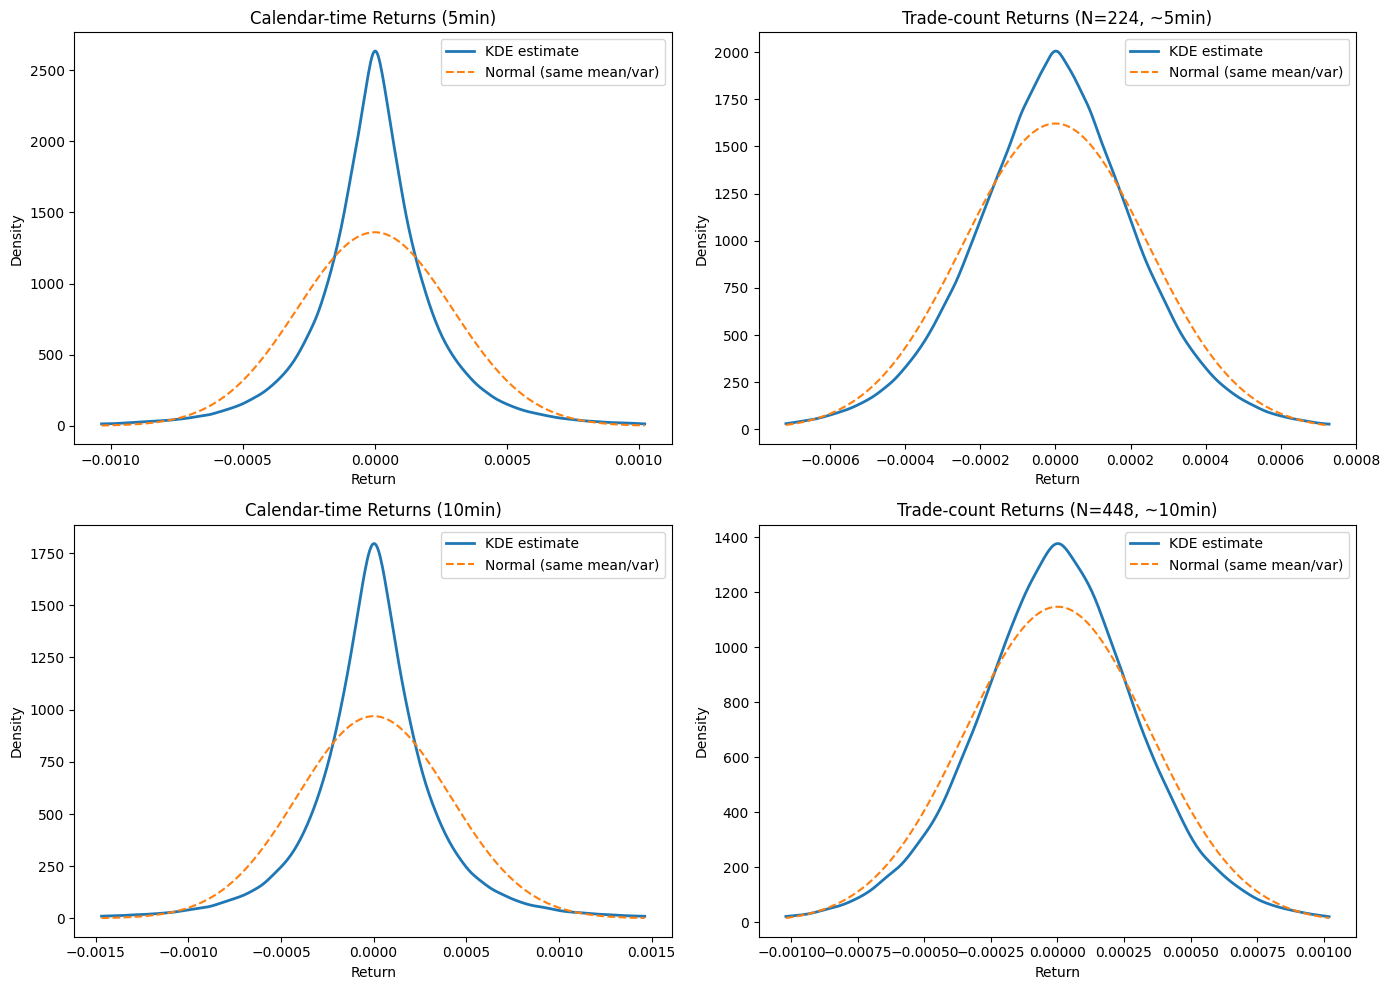

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

series_list = [
    (fivemin_bars['Y'], 'Calendar-time Returns (5min)', axes[0,0]),
    (tradecount_bars_5min_clean['Y'], 'Trade-count Returns (N=224, ~5min)', axes[0,1]),
    (tenmin_bars['Y'], 'Calendar-time Returns (10min)', axes[1,0]),
    (tradecount_bars_10min_clean['Y'], 'Trade-count Returns (N=448, ~10min)', axes[1,1]),
]

for series, title, ax in series_list:
    s = series.dropna()
    n = len(s)
    sigma = s.std()
    h = sigma * (4/3)**(1/5) * n**(-1/5)
    bw_factor = h / sigma
    
    upper = s.quantile(0.995)
    lower = s.quantile(0.005)
    x_range = np.linspace(lower, upper, 500)
    density = gaussian_kde(s, bw_method=bw_factor)(x_range)
    
    mu = s.mean()
    normal_curve = norm.pdf(x_range, mu, sigma)
    
    ax.plot(x_range, density, label='KDE estimate', linewidth=2)
    ax.plot(x_range, normal_curve, label='Normal (same mean/var)', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Return')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

In [42]:
def build_combined_clock_bars(raw_ticks_df, threshold, alpha=0.5):
    df = raw_ticks_df.reset_index()
    
    mean_vol = df['volume'].mean()
    df['combined_score'] = alpha * 1 + (1 - alpha) * (df['volume'] / mean_vol)
    df['cum_score'] = df['combined_score'].cumsum()
    df['bar_id'] = (df['cum_score'] // threshold).astype(int)
    
    bars = df.groupby('bar_id').agg(
        start_time=('timestamp', 'first'),
        end_time=('timestamp', 'last'),
        open=('mid', 'first'),
        high=('mid', 'max'),
        low=('mid', 'min'),
        close=('mid', 'last'),
        vol=('volume', 'sum'),
        tick_count=('mid', 'count'),
    )
    
    bars['duration'] = bars['end_time'] - bars['start_time']
    bars['Y'] = np.log(bars['close'] / bars['close'].shift(1))
    
    return bars

In [43]:
combined_bars_5min = build_combined_clock_bars(raw_ticks, threshold=N_5min)
combined_bars_10min = build_combined_clock_bars(raw_ticks, threshold=N_10min)

combined_bars_5min.shape, combined_bars_10min.shape

((630144, 10), (315072, 10))

In [44]:
combined_bars_5min_clean = clean_tradecount_bars(combined_bars_5min)
combined_bars_10min_clean = clean_tradecount_bars(combined_bars_10min)

combined_bars_5min_clean.shape, combined_bars_10min_clean.shape

Number of bars excluded (weekend-spanning): 315 out of 630144
Number of bars excluded (weekend-spanning): 315 out of 315072


((629514, 10), (314442, 10))

In [45]:
results_comparison.append(get_stats(combined_bars_5min_clean['Y'], 'Combined-clock Returns (~5min equiv)'))
results_comparison.append(get_stats(combined_bars_10min_clean['Y'], 'Combined-clock Returns (~10min equiv)'))

table_comparison_full = pd.DataFrame(results_comparison)
table_comparison_full

,series,mean,variance,m3,m4,m5,m6,skewness,kurtosis
0,Calendar-time Returns (5min),1.846439e-07,8.601713e-08,9.345829e-14,3.568206e-13,3.380015e-16,2.080807e-17,0.003705,48.225873
1,"Trade-count Returns (~5min equiv, N=224)",1.453815e-07,6.053118e-08,-2.262062e-13,5.277563e-14,-1.231572e-17,9.764468e-19,-0.015189,14.403733
2,Calendar-time Returns (10min),3.218748e-07,1.695666e-07,4.073209e-12,9.651908e-13,1.379970e-15,6.252886e-17,0.058335,33.568541
3,"Trade-count Returns (~10min equiv, N=448)",2.485773e-07,1.207718e-07,-2.505918e-12,1.786149e-13,-2.364032e-16,4.321231e-18,-0.059706,12.245794
4,Combined-clock Returns (~5min equiv),1.363737e-07,6.055708e-08,2.554830e-13,6.784602e-14,7.000164e-18,1.939494e-18,0.017144,18.500973
5,Combined-clock Returns (~10min equiv),2.276836e-07,1.207429e-07,7.161038e-13,1.873585e-13,3.958842e-17,4.028709e-18,0.017068,12.851385


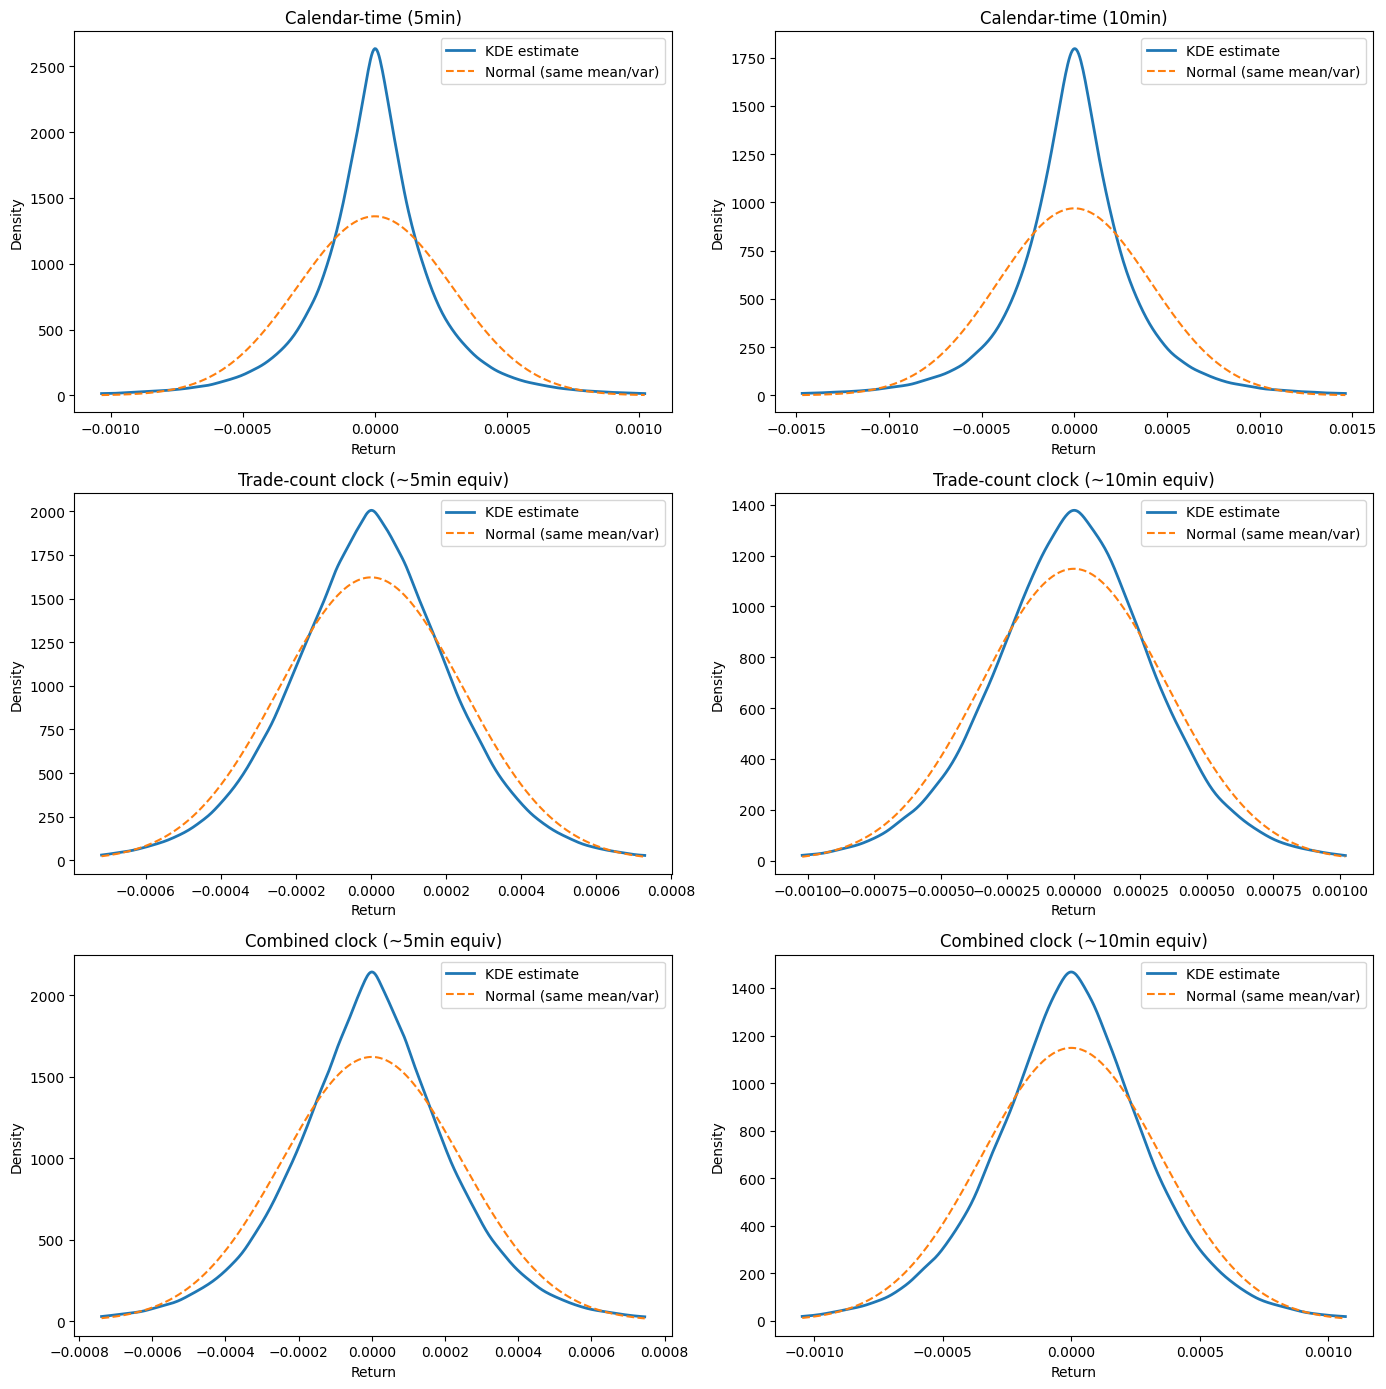

In [46]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

series_list = [
    (fivemin_bars['Y'], 'Calendar-time (5min)', axes[0,0]),
    (tenmin_bars['Y'], 'Calendar-time (10min)', axes[0,1]),
    (tradecount_bars_5min_clean['Y'], 'Trade-count clock (~5min equiv)', axes[1,0]),
    (tradecount_bars_10min_clean['Y'], 'Trade-count clock (~10min equiv)', axes[1,1]),
    (combined_bars_5min_clean['Y'], 'Combined clock (~5min equiv)', axes[2,0]),
    (combined_bars_10min_clean['Y'], 'Combined clock (~10min equiv)', axes[2,1]),
]

for series, title, ax in series_list:
    s = series.dropna()
    n = len(s)
    sigma = s.std()
    h = sigma * (4/3)**(1/5) * n**(-1/5)
    bw_factor = h / sigma
    
    upper = s.quantile(0.995)
    lower = s.quantile(0.005)
    x_range = np.linspace(lower, upper, 500)
    density = gaussian_kde(s, bw_method=bw_factor)(x_range)
    
    mu = s.mean()
    normal_curve = norm.pdf(x_range, mu, sigma)
    
    ax.plot(x_range, density, label='KDE estimate', linewidth=2)
    ax.plot(x_range, normal_curve, label='Normal (same mean/var)', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Return')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

T distribution trial

In [47]:
from scipy.stats import t as t_dist

def fit_and_plot_with_t(series, title, ax):
    s = series.dropna()
    n = len(s)
    sigma = s.std()
    h = sigma * (4/3)**(1/5) * n**(-1/5)
    bw_factor = h / sigma
    
    upper = s.quantile(0.995)
    lower = s.quantile(0.005)
    x_range = np.linspace(lower, upper, 500)
    density = gaussian_kde(s, bw_method=bw_factor)(x_range)
    
    mu = s.mean()
    normal_curve = norm.pdf(x_range, mu, sigma)
    
    # Fit Student's t via MLE
    t_params = t_dist.fit(s)  # returns (df, loc, scale)
    t_curve = t_dist.pdf(x_range, *t_params)
    
    ax.plot(x_range, density, label='KDE estimate', linewidth=2)
    ax.plot(x_range, normal_curve, label='Normal', linestyle='--')
    ax.plot(x_range, t_curve, label=f't-dist (df={t_params[0]:.1f})', linestyle=':')
    ax.set_title(title)
    ax.set_xlabel('Return')
    ax.set_ylabel('Density')
    ax.legend()
    
    return t_params

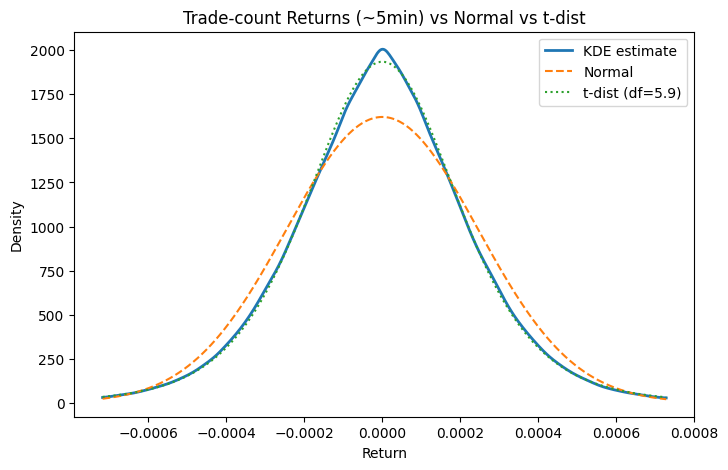

Fitted t-distribution params (df, loc, scale): (np.float64(5.944904902978029), np.float64(1.7971347516566855e-07), np.float64(0.00019773456833828418))


In [48]:
fig, ax = plt.subplots(figsize=(8,5))
params = fit_and_plot_with_t(tradecount_bars_5min_clean['Y'], 'Trade-count Returns (~5min) vs Normal vs t-dist', ax)
plt.show()
print("Fitted t-distribution params (df, loc, scale):", params)

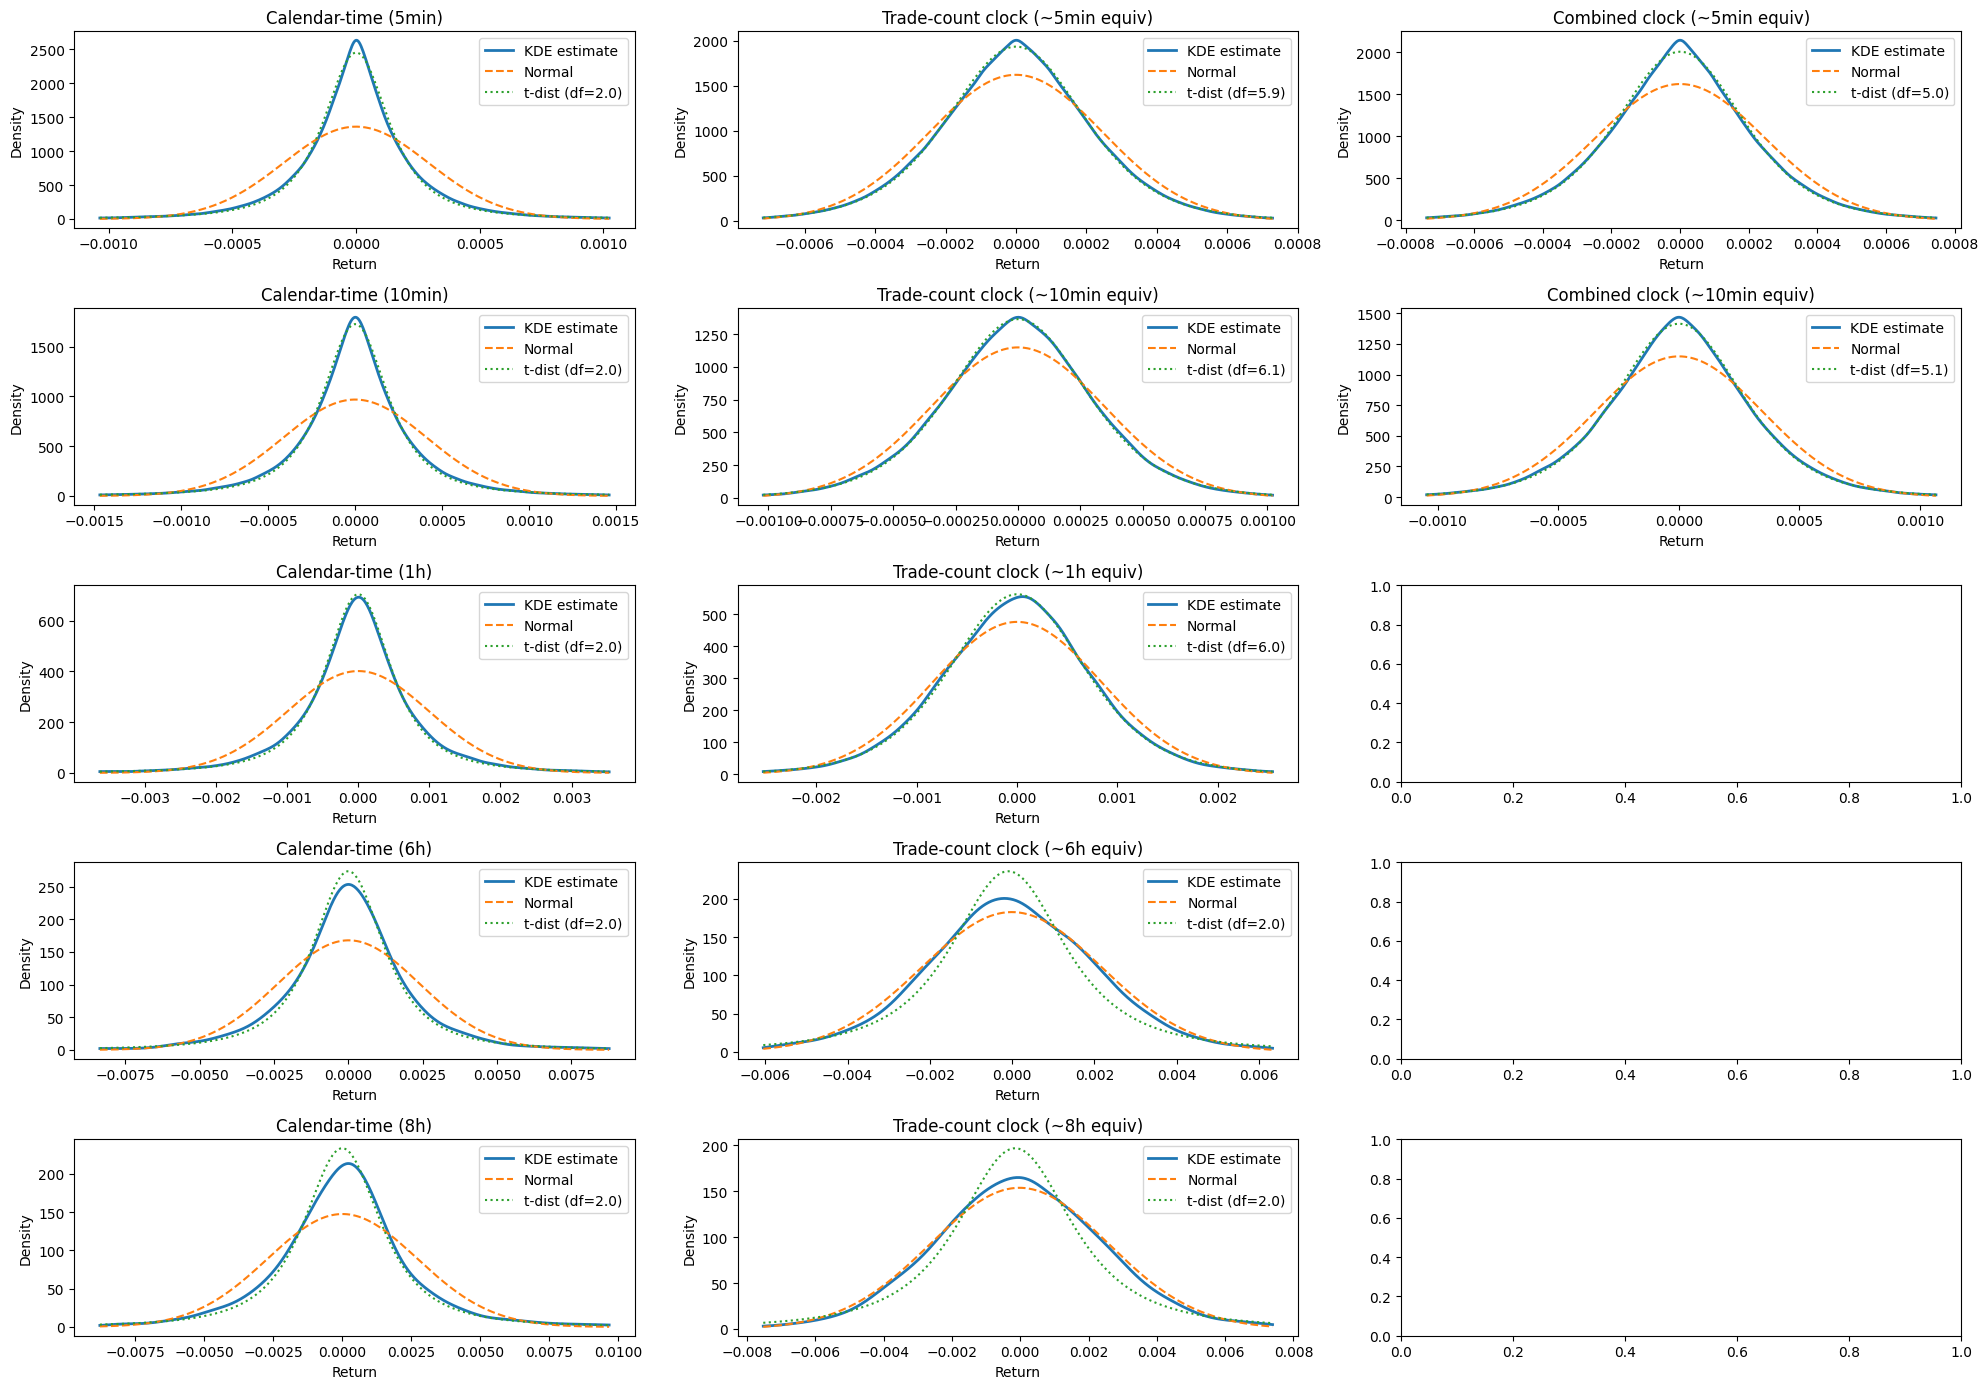

Calendar-time (5min): df=1.99
Calendar-time (10min): df=1.99
Calendar-time (1h): df=1.99
Calendar-time (6h): df=1.99
Calendar-time (8h): df=1.99
Trade-count clock (~5min equiv): df=5.94
Trade-count clock (~10min equiv): df=6.06
Trade-count clock (~1h equiv): df=6.04
Trade-count clock (~6h equiv): df=2.02
Trade-count clock (~8h equiv): df=2.04
Combined clock (~5min equiv): df=5.04
Combined clock (~10min equiv): df=5.10


In [49]:
fig, axes = plt.subplots(5,3, figsize=(20, 14))

series_list = [
    (fivemin_bars['Y'], 'Calendar-time (5min)', axes[0,0]),
    (tenmin_bars['Y'], 'Calendar-time (10min)', axes[1,0]),
    (onehour_bars['Y'], 'Calendar-time (1h)', axes[2,0]),
    (sixhour_bars['Y'], 'Calendar-time (6h)', axes[3,0]),
    (eighthour_bars['Y'], 'Calendar-time (8h)', axes[4,0]),


    (tradecount_bars_5min_clean['Y'], 'Trade-count clock (~5min equiv)', axes[0,1]),
    (tradecount_bars_10min_clean['Y'], 'Trade-count clock (~10min equiv)', axes[1,1]),
    (tradecount_bars_1h_clean['Y'], 'Trade-count clock (~1h equiv)', axes[2,1]),
    (tradecount_bars_6h_clean['Y'], 'Trade-count clock (~6h equiv)', axes[3,1]),
    (tradecount_bars_8h_clean['Y'], 'Trade-count clock (~8h equiv)', axes[4,1]),

    (combined_bars_5min_clean['Y'], 'Combined clock (~5min equiv)', axes[0,2]),
    (combined_bars_10min_clean['Y'], 'Combined clock (~10min equiv)', axes[1,2]),
]

fitted_params = {}

for series, title, ax in series_list:
    params = fit_and_plot_with_t(series, title, ax)
    fitted_params[title] = params

plt.tight_layout()
plt.show()

for title, params in fitted_params.items():
    print(f"{title}: df={params[0]:.2f}")